## DepMap Omics Profiles (bridge table) — `8_DepMap_OmicsProfiles.csv`

Small but critical: 3,830 rows mapping `ProfileID` (`PR-...`) to `ModelID` (`ACH-...`). Three sequencing types: RNA (1,495), WES/exome (1,860), WGS/whole-genome (475). When joining RNA expression or mutation files, filter `Datatype == 'rna'` or `'wes'` first — otherwise you will create duplicates.

In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [2]:
df = pd.read_csv(ini.df8)

In [3]:
df.shape

(3830, 5)

In [4]:
df.head()

,ProfileID,ModelCondition,ModelID,Datatype,WESKit
0,PR-00UtU3,MC-001131-kkJv,ACH-001131,wgs,NaN
1,PR-01r7OM,MC-000957-Yckn,ACH-000957,rna,NaN
2,PR-02XmLG,MC-002785-qo9e,ACH-002785,rna,NaN
3,PR-04VvBz,MC-001289-BpdI,ACH-001289,wes,ICE
4,PR-09gmEI,MC-000520-YIm7,ACH-000520,rna,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3830 entries, 0 to 3829
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ProfileID       3830 non-null   str  
 1   ModelCondition  3830 non-null   str  
 2   ModelID         3830 non-null   str  
 3   Datatype        3830 non-null   str  
 4   WESKit          1860 non-null   str  
dtypes: str(5)
memory usage: 295.6 KB


In [6]:
df["ProfileID"].nunique(), df["ProfileID"].unique()

(3830,
 <ArrowStringArray>
 ['PR-00UtU3', 'PR-01r7OM', 'PR-02XmLG', 'PR-04VvBz', 'PR-09gmEI', 'PR-09S1KU',
  'PR-0B6q0Z', 'PR-0c2Lny', 'PR-0ccWFQ', 'PR-0CHfFI',
  ...
  'PR-zWwfjk', 'PR-zWyHnl', 'PR-ZxbCmO', 'PR-ZXBMUP', 'PR-ZXiFr9', 'PR-zyM15A',
  'PR-ZYtjVT', 'PR-ZzHTvC', 'PR-ZzjQOA', 'PR-ZzPC09']
 Length: 3830, dtype: str)

In [7]:
df["ModelCondition"].nunique(), df["ModelCondition"].unique()

(2540,
 <ArrowStringArray>
 ['MC-001131-kkJv', 'MC-000957-Yckn', 'MC-002785-qo9e', 'MC-001289-BpdI',
  'MC-000520-YIm7', 'MC-002269-tG4R', 'MC-000575-q3Ch', 'MC-000074-Qybw',
  'MC-000869-u5uo', 'MC-001409-HWlo',
  ...
  'MC-000940-SV1H', 'MC-000493-3Cne', 'MC-000991-vB9l', 'MC-003019-6LhD',
  'MC-000091-gNqr', 'MC-001321-4zQP', 'MC-000287-pZ0k', 'MC-002336-stWo',
  'MC-000257-cJZK', 'MC-000662-1qHS']
 Length: 2540, dtype: str)

In [8]:
df["ModelID"].nunique(), df["ModelID"].unique()

(1822,
 <ArrowStringArray>
 ['ACH-001131', 'ACH-000957', 'ACH-002785', 'ACH-001289', 'ACH-000520',
  'ACH-002269', 'ACH-000575', 'ACH-000074', 'ACH-000869', 'ACH-001409',
  ...
  'ACH-001452', 'ACH-002150', 'ACH-002144', 'ACH-000048', 'ACH-000185',
  'ACH-002295', 'ACH-002128', 'ACH-002096', 'ACH-003019', 'ACH-002336']
 Length: 1822, dtype: str)

In [9]:
df["Datatype"].nunique(), df["Datatype"].unique()

(3,
 <ArrowStringArray>
 ['wgs', 'rna', 'wes']
 Length: 3, dtype: str)

In [10]:
df["WESKit"].nunique(), df["WESKit"].unique()

(2,
 <ArrowStringArray>
 [nan, 'ICE', 'AGILENT']
 Length: 3, dtype: str)

### Missing values
Each column should be fully populated except WESKit (only applies to WES runs).

In [11]:
missing = df.isnull().sum().rename("missing")
pct = (missing / len(df) * 100).rename("pct")
print(pd.concat([missing, pct], axis=1).to_string())


                missing        pct
ProfileID             0   0.000000
ModelCondition        0   0.000000
ModelID               0   0.000000
Datatype              0   0.000000
WESKit             1970  51.436031


### Sequencing-type distribution
Each cell line may have up to three sequencing runs: RNA, whole-exome (WES), and whole-genome (WGS). The split matters because each type feeds a different omics file.

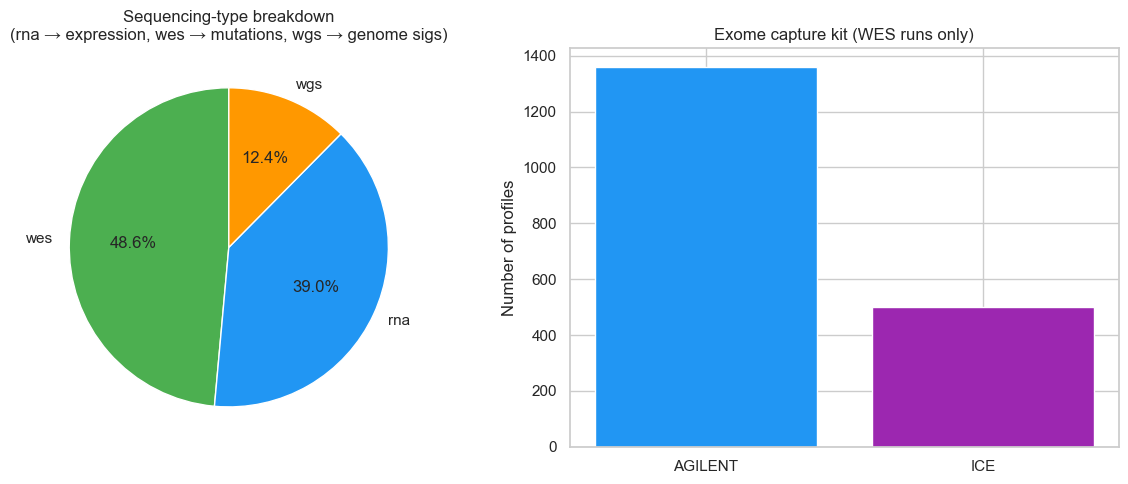

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- pie: datatype ---
dt = df["Datatype"].value_counts()
axes[0].pie(dt.values, labels=dt.index, autopct="%1.1f%%", startangle=90,
            colors=["#4CAF50", "#2196F3", "#FF9800"])
axes[0].set_title("Sequencing-type breakdown\n(rna → expression, wes → mutations, wgs → genome sigs)")

# --- bar: WESKit for wes runs only ---
wk = df[df["Datatype"] == "wes"]["WESKit"].value_counts()
axes[1].bar(wk.index, wk.values, color=["#2196F3", "#9C27B0"])
axes[1].set_title("Exome capture kit (WES runs only)")
axes[1].set_ylabel("Number of profiles")

plt.tight_layout(); plt.show()


### How many sequencing runs per cell line?
Some lines were sequenced multiple times or with multiple methods — here we check how many ProfileIDs map to each ModelID.

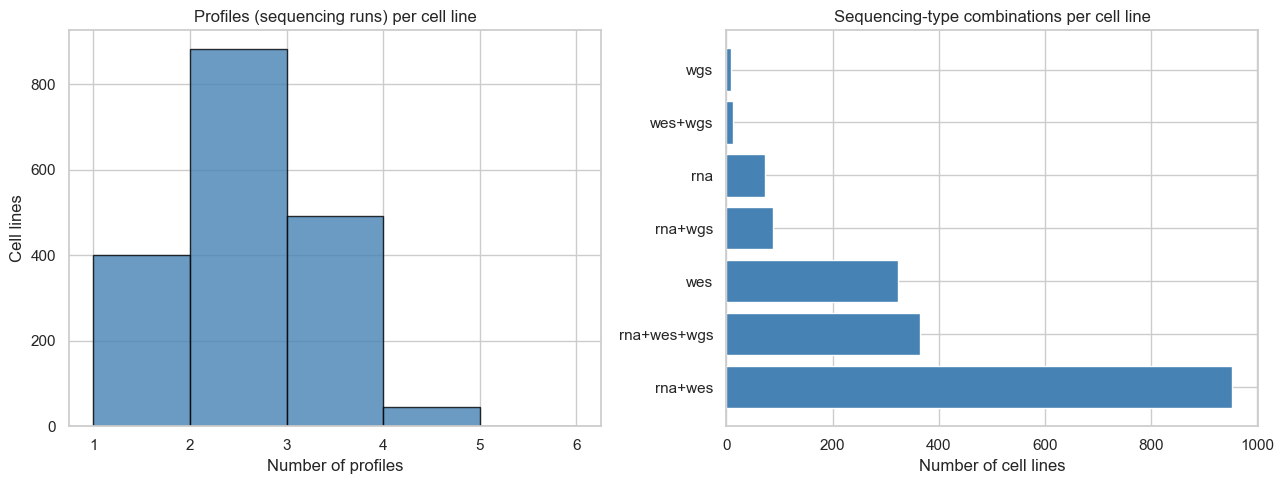

Cell lines with all 3 types: 365


In [13]:
profiles_per_model = df.groupby("ModelID")["ProfileID"].count()
types_per_model   = df.groupby("ModelID")["Datatype"].apply(frozenset)

from collections import Counter
combo_counts = Counter(types_per_model)
combo_labels = ["+".join(sorted(k)) for k in combo_counts]
combo_vals   = list(combo_counts.values())
sort_idx = sorted(range(len(combo_vals)), key=lambda i: -combo_vals[i])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(profiles_per_model, bins=range(1, profiles_per_model.max()+2),
             color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Profiles (sequencing runs) per cell line")
axes[0].set_xlabel("Number of profiles"); axes[0].set_ylabel("Cell lines")

axes[1].barh([combo_labels[i] for i in sort_idx],
             [combo_vals[i]   for i in sort_idx], color="steelblue")
axes[1].set_title("Sequencing-type combinations per cell line")
axes[1].set_xlabel("Number of cell lines")

plt.tight_layout(); plt.show()
print(f"Cell lines with all 3 types: {sum(len(s)==3 for s in types_per_model)}")


### Key findings

In [14]:
print("=== DepMap OmicsProfiles (bridge table) ===")
print(f"Total profiles     : {len(df)}")
print(f"Unique ModelIDs    : {df['ModelID'].nunique()}")
print(f"  rna profiles     : {(df.Datatype=='rna').sum()}  (→ links RNA expression to ModelID)")
print(f"  wes profiles     : {(df.Datatype=='wes').sum()}  (→ links mutation calls to ModelID)")
print(f"  wgs profiles     : {(df.Datatype=='wgs').sum()}  (→ links genome signatures to ModelID)")


=== DepMap OmicsProfiles (bridge table) ===
Total profiles     : 3830
Unique ModelIDs    : 1822
  rna profiles     : 1495  (→ links RNA expression to ModelID)
  wes profiles     : 1860  (→ links mutation calls to ModelID)
  wgs profiles     : 475  (→ links genome signatures to ModelID)


## Join Analysis — how this table connects to the others

df8 IS the bridge table. Every join involving ProfileIDs passes through here.
It has THREE join directions: towards expression/mutations (ProfileID-side),
towards the cell line catalogue (ModelID-side), and consistency checks between them.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df8 | `ProfileID` (rna) | df2 | index (ProfileID) | 1:1 | RNA profiles |
| df8 | `ProfileID` (wes/wgs) | df6 | `ProfileID` | 1:1 | mutation profiles |
| df8 | `ModelID` | df9 | `DepMap_ID` | many:1 | up to 3 profiles per line |

**Why this matters:** If a ProfileID exists in df2 or df6 but NOT in df8,
it cannot be resolved to a cell line — that row becomes orphaned and must be dropped.


In [15]:
# ── A/B: Join coverage in all three directions ───────────────────────────────
df2_tmp    = pd.read_csv(ini.df2, usecols=["Unnamed: 0"])
df6_tmp    = pd.read_csv(ini.df6, usecols=["ProfileID"], low_memory=False)
df9_ids    = pd.read_csv(ini.df9, usecols=["DepMap_ID", "lineage"])

df2_profs  = set(df2_tmp["Unnamed: 0"].dropna())
df6_profs  = set(df6_tmp["ProfileID"].dropna())
df8_rna    = set(df[df["Datatype"] == "rna"]["ProfileID"])
df8_nonrna = set(df[df["Datatype"].isin(["wes","wgs"])]["ProfileID"])
df8_models = set(df["ModelID"])
df9_models = set(df9_ids["DepMap_ID"])

print("=== df8 as bridge: three-direction check ===")
print()
print("─── RNA direction (df8 ↔ df2) ───")
print(f"  df8 rna ProfileIDs : {len(df8_rna)}")
print(f"  df2 ProfileIDs     : {len(df2_profs)}")
print(f"  In df8 only        : {len(df8_rna - df2_profs)}  (df8 has rna profile, df2 missing)")
print(f"  In df2 only        : {len(df2_profs - df8_rna)}  (df2 orphan ProfileIDs)")
print(f"  Matched            : {len(df8_rna & df2_profs)}")
print()
print("─── Mutation direction (df8 ↔ df6) ───")
print(f"  df8 wes+wgs ProfileIDs : {len(df8_nonrna)}")
print(f"  df6 ProfileIDs          : {len(df6_profs)}")
print(f"  In df8 only             : {len(df8_nonrna - df6_profs)}")
print(f"  In df6 only (orphans)   : {len(df6_profs - df8_nonrna)}")
print(f"  Matched                 : {len(df8_nonrna & df6_profs)}")
print()
print("─── Cell line direction (df8 ↔ df9) ───")
print(f"  df8 unique ModelIDs : {len(df8_models)}")
print(f"  df9 DepMap_IDs      : {len(df9_models)}")
print(f"  In df8 only         : {len(df8_models - df9_models)}")
print(f"  In df9 only         : {len(df9_models - df8_models)}")
print(f"  Matched             : {len(df8_models & df9_models)}")


=== df8 as bridge: three-direction check ===

─── RNA direction (df8 ↔ df2) ───
  df8 rna ProfileIDs : 1495
  df2 ProfileIDs     : 1495
  In df8 only        : 0  (df8 has rna profile, df2 missing)
  In df2 only        : 0  (df2 orphan ProfileIDs)
  Matched            : 1495

─── Mutation direction (df8 ↔ df6) ───
  df8 wes+wgs ProfileIDs : 2335
  df6 ProfileIDs          : 2828
  In df8 only             : 6
  In df6 only (orphans)   : 499
  Matched                 : 2329

─── Cell line direction (df8 ↔ df9) ───
  df8 unique ModelIDs : 1822
  df9 DepMap_IDs      : 1840
  In df8 only         : 73
  In df9 only         : 91
  Matched             : 1749


In [16]:
# ── C: Format check on both key columns ─────────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["ProfileID"], "ProfileID (df8)", prefix="PR-")
print()
fmt_check(df["ModelID"], "ModelID (df8)", prefix="ACH-")
print()
# Consistency: does every ProfileID in df2 map to exactly one ModelID in df8?
multi_model = (df[df["Datatype"]=="rna"].groupby("ProfileID")["ModelID"].nunique() > 1)
print(f"RNA ProfileIDs mapping to >1 ModelID: {multi_model.sum()}  (should be 0)")


Format check — ProfileID (df8) (n=3830 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'PR-'  : True
  Length range        : 9 – 9
  Duplicates          : 0

Format check — ModelID (df8) (n=3830 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'ACH-'  : True
  Length range        : 10 – 10
  Duplicates          : 2008

RNA ProfileIDs mapping to >1 ModelID: 0  (should be 0)


### Biological implications

df8 is the only file that resolves ProfileIDs to ModelIDs. Any orphaned ProfileID in
df2 or df6 (not in df8) represents a profile for which we have omics data but no
cell line annotation — these rows must be excluded from training.

The coverage gap between df8 ModelIDs and df9 DepMap_IDs tells us how many cell lines
in the catalogue have no sequencing profiles at all — these lines appear in df9 for
metadata purposes but contribute no omics features.


In [17]:
# Biological: cell lines in df9 that have no profiles in df8
no_profile = df9_ids[~df9_ids["DepMap_ID"].isin(df8_models)]
print("Lineages with NO sequencing profile in df8 (top 10):")
print(no_profile["lineage"].value_counts().head(10).to_string())
print(f"\nTotal df9 lines with no omics profile: {len(no_profile)}")


Lineages with NO sequencing profile in df8 (top 10):
lineage
breast                    17
lung                      11
bone                      10
skin                       7
colorectal                 6
central_nervous_system     5
kidney                     4
soft_tissue                4
upper_aerodigestive        4
blood                      3

Total df9 lines with no omics profile: 91


## Join Analysis — how this table connects to the others

df8 IS the bridge table. Every join involving ProfileIDs passes through here.
It has THREE join directions: towards expression/mutations (ProfileID-side),
towards the cell line catalogue (ModelID-side), and consistency checks between them.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df8 | `ProfileID` (rna) | df2 | index (ProfileID) | 1:1 | RNA profiles |
| df8 | `ProfileID` (wes/wgs) | df6 | `ProfileID` | 1:1 | mutation profiles |
| df8 | `ModelID` | df9 | `DepMap_ID` | many:1 | up to 3 profiles per line |

**Why this matters:** If a ProfileID exists in df2 or df6 but NOT in df8,
it cannot be resolved to a cell line — that row becomes orphaned and must be dropped.


In [18]:
# ── A/B: Join coverage in all three directions ───────────────────────────────
df2_tmp    = pd.read_csv(ini.df2, usecols=["Unnamed: 0"])
df6_tmp    = pd.read_csv(ini.df6, usecols=["ProfileID"], low_memory=False)
df9_ids    = pd.read_csv(ini.df9, usecols=["DepMap_ID", "lineage"])

df2_profs  = set(df2_tmp["Unnamed: 0"].dropna())
df6_profs  = set(df6_tmp["ProfileID"].dropna())
df8_rna    = set(df[df["Datatype"] == "rna"]["ProfileID"])
df8_nonrna = set(df[df["Datatype"].isin(["wes","wgs"])]["ProfileID"])
df8_models = set(df["ModelID"])
df9_models = set(df9_ids["DepMap_ID"])

print("=== df8 as bridge: three-direction check ===")
print()
print("─── RNA direction (df8 ↔ df2) ───")
print(f"  df8 rna ProfileIDs : {len(df8_rna)}")
print(f"  df2 ProfileIDs     : {len(df2_profs)}")
print(f"  In df8 only        : {len(df8_rna - df2_profs)}  (df8 has rna profile, df2 missing)")
print(f"  In df2 only        : {len(df2_profs - df8_rna)}  (df2 orphan ProfileIDs)")
print(f"  Matched            : {len(df8_rna & df2_profs)}")
print()
print("─── Mutation direction (df8 ↔ df6) ───")
print(f"  df8 wes+wgs ProfileIDs : {len(df8_nonrna)}")
print(f"  df6 ProfileIDs          : {len(df6_profs)}")
print(f"  In df8 only             : {len(df8_nonrna - df6_profs)}")
print(f"  In df6 only (orphans)   : {len(df6_profs - df8_nonrna)}")
print(f"  Matched                 : {len(df8_nonrna & df6_profs)}")
print()
print("─── Cell line direction (df8 ↔ df9) ───")
print(f"  df8 unique ModelIDs : {len(df8_models)}")
print(f"  df9 DepMap_IDs      : {len(df9_models)}")
print(f"  In df8 only         : {len(df8_models - df9_models)}")
print(f"  In df9 only         : {len(df9_models - df8_models)}")
print(f"  Matched             : {len(df8_models & df9_models)}")


=== df8 as bridge: three-direction check ===

─── RNA direction (df8 ↔ df2) ───
  df8 rna ProfileIDs : 1495
  df2 ProfileIDs     : 1495
  In df8 only        : 0  (df8 has rna profile, df2 missing)
  In df2 only        : 0  (df2 orphan ProfileIDs)
  Matched            : 1495

─── Mutation direction (df8 ↔ df6) ───
  df8 wes+wgs ProfileIDs : 2335
  df6 ProfileIDs          : 2828
  In df8 only             : 6
  In df6 only (orphans)   : 499
  Matched                 : 2329

─── Cell line direction (df8 ↔ df9) ───
  df8 unique ModelIDs : 1822
  df9 DepMap_IDs      : 1840
  In df8 only         : 73
  In df9 only         : 91
  Matched             : 1749


In [19]:
# ── C: Format check on both key columns ─────────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["ProfileID"], "ProfileID (df8)", prefix="PR-")
print()
fmt_check(df["ModelID"], "ModelID (df8)", prefix="ACH-")
print()
# Consistency: does every ProfileID in df2 map to exactly one ModelID in df8?
multi_model = (df[df["Datatype"]=="rna"].groupby("ProfileID")["ModelID"].nunique() > 1)
print(f"RNA ProfileIDs mapping to >1 ModelID: {multi_model.sum()}  (should be 0)")


Format check — ProfileID (df8) (n=3830 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'PR-'  : True
  Length range        : 9 – 9
  Duplicates          : 0

Format check — ModelID (df8) (n=3830 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'ACH-'  : True
  Length range        : 10 – 10
  Duplicates          : 2008

RNA ProfileIDs mapping to >1 ModelID: 0  (should be 0)


### Biological implications

df8 is the only file that resolves ProfileIDs to ModelIDs. Any orphaned ProfileID in
df2 or df6 (not in df8) represents a profile for which we have omics data but no
cell line annotation — these rows must be excluded from training.

The coverage gap between df8 ModelIDs and df9 DepMap_IDs tells us how many cell lines
in the catalogue have no sequencing profiles at all — these lines appear in df9 for
metadata purposes but contribute no omics features.


In [20]:
# Biological: cell lines in df9 that have no profiles in df8
no_profile = df9_ids[~df9_ids["DepMap_ID"].isin(df8_models)]
print("Lineages with NO sequencing profile in df8 (top 10):")
print(no_profile["lineage"].value_counts().head(10).to_string())
print(f"\nTotal df9 lines with no omics profile: {len(no_profile)}")


Lineages with NO sequencing profile in df8 (top 10):
lineage
breast                    17
lung                      11
bone                      10
skin                       7
colorectal                 6
central_nervous_system     5
kidney                     4
soft_tissue                4
upper_aerodigestive        4
blood                      3

Total df9 lines with no omics profile: 91


## Deeper dive: which cell lines are multi-omics-ready?

Each model carries a *combination* of assay types. The combination decides which models
a multi-omics model can use. Lines with all three (`rna+wes+wgs`) are the gold-standard
fully-characterised set.

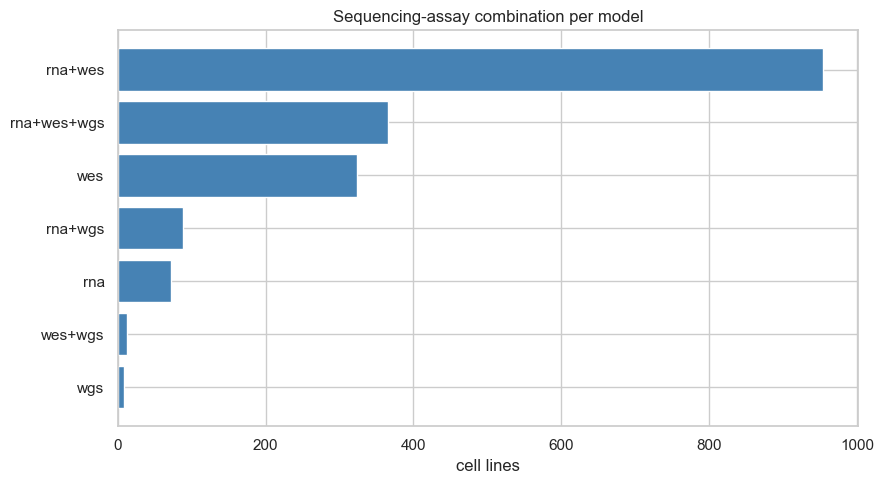

Datatype
rna+wes        954
rna+wes+wgs    365
wes            323
rna+wgs         88
rna             72
wes+wgs         12
wgs              8

Fully characterised (rna+wes+wgs): 365 models


In [21]:
combo = df.groupby("ModelID")["Datatype"].apply(lambda s: "+".join(sorted(set(s))))
vc = combo.value_counts()
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(vc.index[::-1], vc.values[::-1], color="steelblue")
ax.set_xlabel("cell lines"); ax.set_title("Sequencing-assay combination per model")
plt.tight_layout(); plt.show()
print(vc.to_string())
print(f"\nFully characterised (rna+wes+wgs): {vc.get('rna+wes+wgs',0)} models")

## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
This is a small but crucial **translator slip**. Many of the measurement files label their data by a **measurement-run ID** (`ProfileID`, like `PR-xxxxxx`) instead of by the cell line itself. This file is the lookup table that says *"measurement run PR-1234 was performed on cell line ACH-5678, and it was an RNA (or DNA) experiment."* It turns anonymous run IDs into real cell-line IDs.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- **3,830 rows** mapping `ProfileID` → `ModelID`, tagged with the assay `Datatype` (**rna**, **wes**, or **wgs** — different kinds of measurement).
- 3,830 runs collapse to **1,822 unique cell lines** (a line can have several runs).
- The **RNA mapping is a perfect 1:1** with the expression file; the mutation mapping covers ~82%.

Next steps (preprocessing):
- **Use this as the join key everywhere** a file is labelled by `ProfileID`.
- **Always filter by `Datatype` first** (e.g., pick only `rna` rows before joining to the RNA file), otherwise you'd mix measurement types.

Still missing in EDA: nothing — it's plumbing, and it works.

### 3. Which ML approach fits this dataset
**Neither — this is not a model input.** It's an **ID-mapping / plumbing table**. It carries no biological measurements to learn from; its entire value is resolving `ProfileID → ModelID` so the measurement files can be attached to the right cell lines.

> **Big-picture note:** This is the connector that lets the RNA and mutation files reach the DepMap spine — essential infrastructure, but never something the model "reads" as features.